# Predicting Heart Disease Risk from Self-Reported Health Indicators

#Setup and Data Loading

### Environment Setup

In [1]:
import sys, subprocess
for pkg in ["numpy", "pandas", "scikit-learn", "matplotlib", "xgboost"]:
    try:
        __import__(pkg if pkg != "scikit-learn" else "sklearn")
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg])

DATA_URL = "https://raw.githubusercontent.com/doguilmak/Heart-Diseaseor-Attack-Classification/main/heart_disease_health_indicators_BRFSS2015.csv"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve, confusion_matrix)
from xgboost import XGBClassifier
import itertools

TARGET = "HeartDiseaseorAttack"
RAW_FEATURE_COLS = [
    "HighBP", "HighChol", "CholCheck", "BMI", "Smoker", "Stroke", "Diabetes",
    "PhysActivity", "Fruits", "Veggies", "HvyAlcoholConsump", "AnyHealthcare",
    "NoDocbcCost", "GenHlth", "MentHlth", "PhysHlth", "DiffWalk", "Sex",
    "Age", "Education", "Income",
]
BINARY_COLS = [
    TARGET, "HighBP", "HighChol", "CholCheck", "Smoker", "Stroke",
    "PhysActivity", "Fruits", "Veggies", "HvyAlcoholConsump", "AnyHealthcare",
    "NoDocbcCost", "DiffWalk", "Sex",
]
ORDINAL_RANGES = {
    "Diabetes": (0, 2), "GenHlth": (1, 5), "Age": (1, 13),
    "Education": (1, 6), "Income": (1, 8),
    "MentHlth": (0, 30), "PhysHlth": (0, 30),
}
print("Environment ready.")

Environment ready.


### Data Inspection

In [2]:
raw = pd.read_csv(DATA_URL)
print(f"Shape: {raw.shape[0]:,} rows x {raw.shape[1]} columns")
print(raw.dtypes.value_counts())
print(raw[TARGET].value_counts(normalize=True))

Shape: 253,680 rows x 22 columns
float64    22
Name: count, dtype: int64
HeartDiseaseorAttack
0.0    0.905814
1.0    0.094186
Name: proportion, dtype: float64


# Data Cleaning and Validation

### Missing Values and Schema Validation

In [3]:
n_missing = int(raw.isnull().sum().sum())
print(f"Total missing values: {n_missing}")

bad_binary = {c: sorted(set(raw[c].unique()) - {0.0, 1.0}) for c in BINARY_COLS}
bad_binary = {c: v for c, v in bad_binary.items() if v}
print(f"Binary columns with values outside {{0,1}}: {bad_binary or 'none found'}")

bad_ordinal = {}
for c, (lo, hi) in ORDINAL_RANGES.items():
    n_out = int(((raw[c] < lo) | (raw[c] > hi)).sum())
    if n_out:
        bad_ordinal[c] = n_out
print(f"Ordinal columns outside their documented codebook range: {bad_ordinal or 'none found'}")

Total missing values: 0
Binary columns with values outside {0,1}: none found
Ordinal columns outside their documented codebook range: none found


### Duplicate Rows and BMI Range Check

In [4]:
clean = raw.copy()
n_dupe = int(clean.duplicated().sum())
print(f"Exact duplicate rows: {n_dupe:,} ({n_dupe/len(clean):.2%})")

n_extreme_bmi = int(((clean["BMI"] < 12) | (clean["BMI"] > 80)).sum())
print(f"BMI range {clean['BMI'].min():.0f}-{clean['BMI'].max():.0f}, "
      f"{n_extreme_bmi} rows ({n_extreme_bmi/len(clean):.2%}) have BMI > 80. Kept: plausible, not codebook-invalid.")

Exact duplicate rows: 23,899 (9.42%)
BMI range 12-98, 279 rows (0.11%) have BMI > 80. Kept: plausible, not codebook-invalid.


### Dtype Correction

In [5]:
int_cols = [c for c in (BINARY_COLS + list(ORDINAL_RANGES.keys())) if c in clean.columns]
clean[int_cols] = clean[int_cols].astype("int64")
print(f"Cast {len(int_cols)} whole-number-coded columns from float64 to int64.")

Cast 21 whole-number-coded columns from float64 to int64.


# Feature Engineering and Data Splitting

### Feature Engineering and Feature Selection

In [6]:
def engineer_features(df):
    df = df.copy()
    df["comorbidity_count"] = (
        df["HighBP"] + df["HighChol"] + (df["Diabetes"] >= 1).astype(float)
        + df["Stroke"] + df["DiffWalk"]
    )
    df["unhealthy_days_30"] = df["MentHlth"] + df["PhysHlth"]
    df["poor_gen_health"] = (df["GenHlth"] >= 4).astype(float)
    return df

ENGINEERED_COLS = ["comorbidity_count", "unhealthy_days_30", "poor_gen_health"]
FEATURE_COLS = RAW_FEATURE_COLS + ENGINEERED_COLS

featured = engineer_features(clean)
print(featured[ENGINEERED_COLS].describe())

corr_with_target = featured[FEATURE_COLS + [TARGET]].corr()[TARGET].drop(TARGET).sort_values(ascending=False)
print(corr_with_target)

       comorbidity_count  unhealthy_days_30  poor_gen_health
count      253680.000000      253680.000000    253680.000000
mean            1.219505           7.426853         0.172071
std             1.183750          13.291279         0.377443
min             0.000000           0.000000         0.000000
25%             0.000000           0.000000         0.000000
50%             1.000000           1.000000         0.000000
75%             2.000000           7.000000         0.000000
max             5.000000          60.000000         1.000000
comorbidity_count    0.318514
GenHlth              0.258383
poor_gen_health      0.240414
Age                  0.221618
DiffWalk             0.212709
HighBP               0.209361
Stroke               0.203002
PhysHlth             0.181698
HighChol             0.180765
Diabetes             0.180272
unhealthy_days_30    0.155219
Smoker               0.114441
Sex                  0.086096
MentHlth             0.064621
BMI                  0.052904
C

### Validation Leakage Demonstration

In [7]:
def fit_eval(df, seed):
    tr, te = train_test_split(df, test_size=0.2, stratify=df[TARGET], random_state=seed)
    X_tr, y_tr = tr[FEATURE_COLS].values, tr[TARGET].values
    X_te, y_te = te[FEATURE_COLS].values, te[TARGET].values
    model = RandomForestClassifier(n_estimators=200, max_depth=None, min_samples_leaf=1, random_state=0, n_jobs=-1)
    model.fit(X_tr, y_tr)
    proba = model.predict_proba(X_te)[:, 1]
    pred = model.predict(X_te)
    return accuracy_score(y_te, pred), roc_auc_score(y_te, proba)

N_REPEATS = 8
SUBSAMPLE_N = 40000
raw_sub = featured.sample(n=SUBSAMPLE_N, random_state=0).reset_index(drop=True)
deduped_sub = raw_sub.drop_duplicates().reset_index(drop=True)
print(f"Subsample: {len(raw_sub):,} rows | de-duplicated: {len(deduped_sub):,} rows")

naive_acc, naive_auc, proper_acc, proper_auc = [], [], [], []
for seed in range(N_REPEATS):
    a, u = fit_eval(raw_sub, seed); naive_acc.append(a); naive_auc.append(u)
    a, u = fit_eval(deduped_sub, seed); proper_acc.append(a); proper_auc.append(u)
naive_acc, naive_auc = np.array(naive_acc), np.array(naive_auc)
proper_acc, proper_auc = np.array(proper_acc), np.array(proper_auc)
print(f"Naive (raw) split:   acc={naive_acc.mean():.4f}  AUC={naive_auc.mean():.4f}")
print(f"Proper (deduped) split: acc={proper_acc.mean():.4f}  AUC={proper_auc.mean():.4f}")
print(f"Optimistic gap: acc {naive_acc.mean()-proper_acc.mean():+.4f}, AUC {naive_auc.mean()-proper_auc.mean():+.4f}")

Subsample: 40,000 rows | de-duplicated: 38,629 rows
Naive (raw) split:   acc=0.9067  AUC=0.8266
Proper (deduped) split: acc=0.9036  AUC=0.8108
Optimistic gap: acc +0.0031, AUC +0.0158


### Final De-duplication and Split

In [8]:
full = featured.drop_duplicates().reset_index(drop=True)
print(f"After removing duplicates: {len(full):,} unique rows (from {len(featured):,})")

def split_dataset(df, test_size=0.2, val_size=0.2, seed=0):
    train_val, test = train_test_split(df, test_size=test_size, stratify=df[TARGET], random_state=seed)
    val_frac = val_size / (1 - test_size)
    train, val = train_test_split(train_val, test_size=val_frac, stratify=train_val[TARGET], random_state=seed)
    return train.reset_index(drop=True), val.reset_index(drop=True), test.reset_index(drop=True)

train, val, test = split_dataset(full)
print(f"Train: {len(train):,}  Val: {len(val):,}  Test: {len(test):,}")
for name, split in [("Full", full), ("Train", train), ("Val", val), ("Test", test)]:
    print(f"{name:6s} positive-class rate: {split[TARGET].mean():.4f}")

After removing duplicates: 229,781 unique rows (from 253,680)
Train: 137,868  Val: 45,956  Test: 45,957
Full   positive-class rate: 0.1032
Train  positive-class rate: 0.1032
Val    positive-class rate: 0.1032
Test   positive-class rate: 0.1032


### Diagnostic Plots

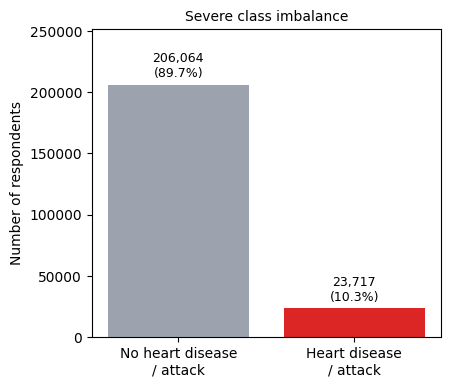

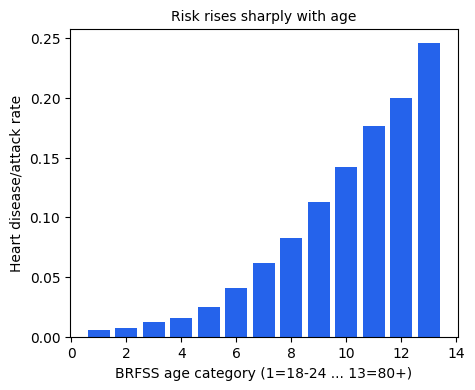

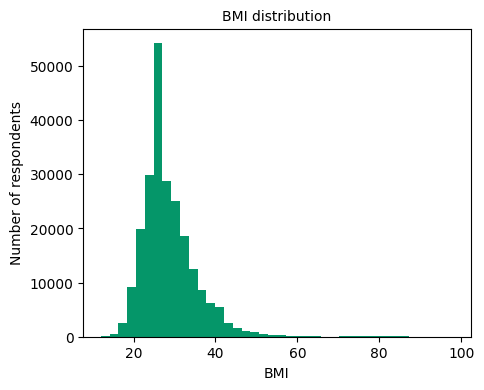

In [9]:
fig, ax = plt.subplots(figsize=(4.5, 4))
counts = full[TARGET].value_counts().sort_index()
ax.bar(["No heart disease\n/ attack", "Heart disease\n/ attack"], counts.values, color=["#9ca3af", "#dc2626"])
ax.set_ylim(0, counts.values.max() * 1.22)
for i, v in enumerate(counts.values):
    ax.text(i, v + counts.values.max()*0.03, f"{v:,}\n({v/len(full):.1%})", ha="center", fontsize=9)
ax.set_ylabel("Number of respondents")
ax.set_title("Severe class imbalance", fontsize=10)
plt.show()

fig, ax = plt.subplots(figsize=(5, 4))
rate_by_age = full.groupby("Age")[TARGET].mean()
ax.bar(rate_by_age.index, rate_by_age.values, color="#2563eb")
ax.set_xlabel("BRFSS age category (1=18-24 ... 13=80+)")
ax.set_ylabel("Heart disease/attack rate")
ax.set_title("Risk rises sharply with age", fontsize=10)
plt.show()

fig, ax = plt.subplots(figsize=(5, 4))
ax.hist(full["BMI"], bins=40, color="#059669")
ax.set_xlabel("BMI")
ax.set_ylabel("Number of respondents")
ax.set_title("BMI distribution", fontsize=10)
plt.show()

# Model Building and Comparison

### Training the Basline, Logistic Regression, Random Forest and XGBoost

In [10]:
def evaluate(name, y_true, y_pred, y_proba=None):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_proba) if y_proba is not None else float("nan")
    print(f"{name:28s} acc={acc:.4f}  prec={prec:.4f}  rec={rec:.4f}  F1={f1:.4f}  AUC={auc:.4f}")
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "auc": auc}

def confusion_plot(y_true, y_pred, title):
    """One shared plotting function so every model gets a matching confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4.4, 4))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["No disease", "Disease"]); ax.set_yticklabels(["No disease", "Disease"])
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_title(title, fontsize=10)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i,j]:,}", ha="center", va="center", color="white" if cm[i,j] > cm.max()/2 else "black")
    fig.colorbar(im, ax=ax, shrink=0.8)
    plt.show()
    return cm

Xtr, ytr = train[FEATURE_COLS].values, train[TARGET].values
Xval, yval = val[FEATURE_COLS].values, val[TARGET].values
Xte, yte = test[FEATURE_COLS].values, test[TARGET].values

results = {}

print("\n-- Naive baseline --")
majority = int(round(ytr.mean())) if ytr.mean() != 0.5 else 0
base_pred = np.full_like(yte, majority)
results["baseline"] = evaluate("Naive baseline", yte, base_pred)

print("\n-- Logistic Regression --")
logreg = make_pipeline(StandardScaler(), LogisticRegression(solver="lbfgs", max_iter=1000))
logreg.fit(Xtr, ytr)
lr_pred = logreg.predict(Xte)
lr_proba = logreg.predict_proba(Xte)[:, 1]
results["logreg"] = evaluate("Logistic Regression", yte, lr_pred, lr_proba)

print("\n-- Random Forest: validation grid search --")
param_grid = list(itertools.product([4, 6, 8, 10], [20, 50]))
best_val_auc, best_params = -1, None
for max_depth, min_leaf in param_grid:
    rf = RandomForestClassifier(n_estimators=300, max_depth=max_depth, min_samples_leaf=min_leaf, random_state=0, n_jobs=-1)
    rf.fit(Xtr, ytr)
    val_auc = roc_auc_score(yval, rf.predict_proba(Xval)[:, 1])
    print(f"  max_depth={max_depth}, min_samples_leaf={min_leaf}: val AUC={val_auc:.4f}")
    if val_auc > best_val_auc:
        best_val_auc, best_params = val_auc, (max_depth, min_leaf)
print(f"\nBest RF hyperparameters (val AUC={best_val_auc:.4f}): "
      f"max_depth={best_params[0]}, min_samples_leaf={best_params[1]}")

print("\n-- Random Forest: final fit and test-set evaluation --")
Xdev = np.vstack([Xtr, Xval]); ydev = np.concatenate([ytr, yval])
rf_final = RandomForestClassifier(n_estimators=300, max_depth=best_params[0], min_samples_leaf=best_params[1], random_state=0, n_jobs=-1)
rf_final.fit(Xdev, ydev)
rf_pred = rf_final.predict(Xte)
rf_proba = rf_final.predict_proba(Xte)[:, 1]
results["random_forest"] = evaluate("Random Forest (tuned)", yte, rf_pred, rf_proba)
rf_val_proba = rf_final.predict_proba(Xval)[:, 1]

print("\n-- XGBoost: validation grid search --")
xgb_param_grid = list(itertools.product([3, 4, 5, 6], [0.05, 0.1]))
best_xgb_val_auc, best_xgb_params = -1, None
for max_depth, learning_rate in xgb_param_grid:
    xgb = XGBClassifier(n_estimators=300, max_depth=max_depth, learning_rate=learning_rate,
                         random_state=0, n_jobs=-1, eval_metric="logloss")
    xgb.fit(Xtr, ytr)
    val_auc = roc_auc_score(yval, xgb.predict_proba(Xval)[:, 1])
    print(f"  max_depth={max_depth}, learning_rate={learning_rate}: val AUC={val_auc:.4f}")
    if val_auc > best_xgb_val_auc:
        best_xgb_val_auc, best_xgb_params = val_auc, (max_depth, learning_rate)
print(f"\nBest XGBoost hyperparameters (val AUC={best_xgb_val_auc:.4f}): "
      f"max_depth={best_xgb_params[0]}, learning_rate={best_xgb_params[1]}")

print("\n-- XGBoost: final fit and test-set evaluation (primary model) --")
xgb_final = XGBClassifier(n_estimators=300, max_depth=best_xgb_params[0], learning_rate=best_xgb_params[1],
                           random_state=0, n_jobs=-1, eval_metric="logloss")
xgb_final.fit(Xdev, ydev)
xgb_pred = xgb_final.predict(Xte)
xgb_proba = xgb_final.predict_proba(Xte)[:, 1]
results["xgboost"] = evaluate("XGBoost (tuned, primary model)", yte, xgb_pred, xgb_proba)
xgb_val_proba = xgb_final.predict_proba(Xval)[:, 1]



-- Naive baseline --
Naive baseline               acc=0.8968  prec=0.0000  rec=0.0000  F1=0.0000  AUC=nan

-- Logistic Regression --
Logistic Regression          acc=0.8987  prec=0.5403  rec=0.1257  F1=0.2039  AUC=0.8308

-- Random Forest: validation grid search --
  max_depth=4, min_samples_leaf=20: val AUC=0.8161
  max_depth=4, min_samples_leaf=50: val AUC=0.8161
  max_depth=6, min_samples_leaf=20: val AUC=0.8253
  max_depth=6, min_samples_leaf=50: val AUC=0.8249
  max_depth=8, min_samples_leaf=20: val AUC=0.8309
  max_depth=8, min_samples_leaf=50: val AUC=0.8306
  max_depth=10, min_samples_leaf=20: val AUC=0.8339
  max_depth=10, min_samples_leaf=50: val AUC=0.8335

Best RF hyperparameters (val AUC=0.8339): max_depth=10, min_samples_leaf=20

-- Random Forest: final fit and test-set evaluation --
Random Forest (tuned)        acc=0.8994  prec=0.6460  rec=0.0550  F1=0.1014  AUC=0.8300

-- XGBoost: validation grid search --
  max_depth=3, learning_rate=0.05: val AUC=0.8385
  max_depth=3

### Combined Results Table

In [11]:
name_by_key = {"baseline": "Naive baseline", "logreg": "Logistic Regression",
               "random_forest": "Random Forest (tuned)", "xgboost": "XGBoost (tuned, primary model)"}
header = f"{'Model':30s}  {'Accuracy':>9s}  {'Precision':>10s}  {'Recall':>8s}  {'F1':>8s}  {'ROC-AUC':>8s}"
print()
print(header)
print("-" * len(header))
for key, name in name_by_key.items():
    r = results[key]
    auc_str = f"{r['auc']:.4f}" if r["auc"] == r["auc"] else "n/a"
    print(f"{name:30s}  {r['accuracy']:9.4f}  {r['precision']:10.4f}  {r['recall']:8.4f}  {r['f1']:8.4f}  {auc_str:>8s}")



Model                            Accuracy   Precision    Recall        F1   ROC-AUC
-----------------------------------------------------------------------------------
Naive baseline                     0.8968      0.0000    0.0000    0.0000       n/a
Logistic Regression                0.8987      0.5403    0.1257    0.2039    0.8308
Random Forest (tuned)              0.8994      0.6460    0.0550    0.1014    0.8300
XGBoost (tuned, primary model)     0.8994      0.5763    0.0964    0.1651    0.8354


### Confusion Matrix, Naive Baseline

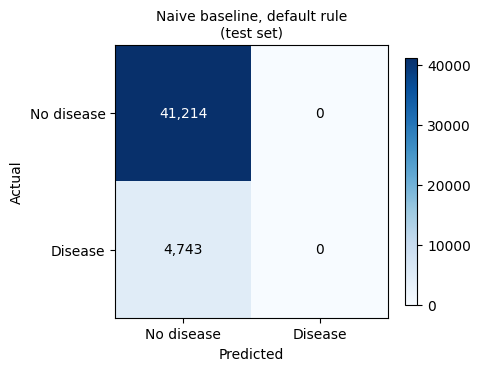

array([[41214,     0],
       [ 4743,     0]])

In [12]:
confusion_plot(yte, base_pred, "Naive baseline, default rule\n(test set)")

### Confusion Matrix, Logistic Regression

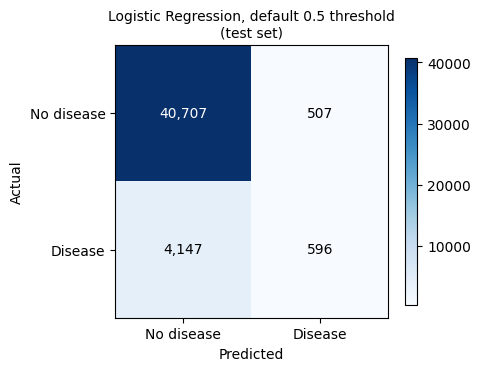

array([[40707,   507],
       [ 4147,   596]])

In [13]:
confusion_plot(yte, lr_pred, "Logistic Regression, default 0.5 threshold\n(test set)")

### Confusion Matrix, Random Forest

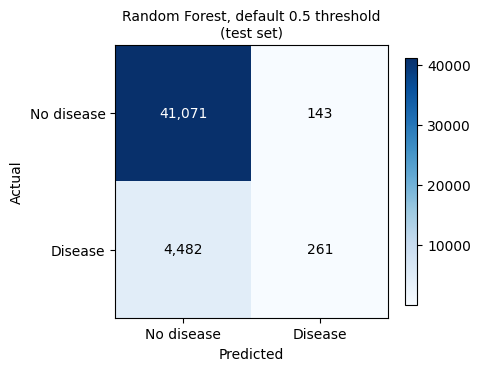

array([[41071,   143],
       [ 4482,   261]])

In [14]:
confusion_plot(yte, rf_pred, "Random Forest, default 0.5 threshold\n(test set)")

### Confusion Matrix, XGBoost

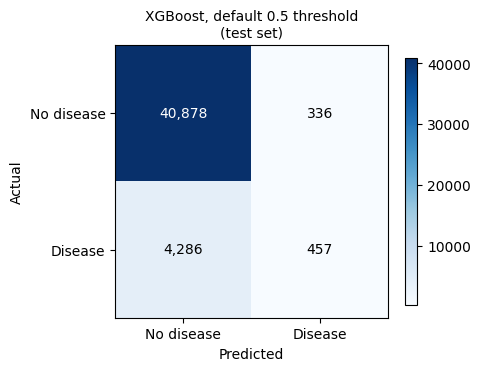

array([[40878,   336],
       [ 4286,   457]])

In [15]:
confusion_plot(yte, xgb_pred, "XGBoost, default 0.5 threshold\n(test set)")

### ROC Curves

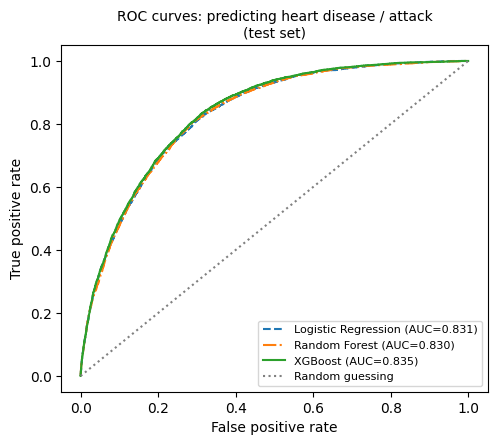

In [16]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
for name, proba, style in [("Logistic Regression", lr_proba, "--"),
                            ("Random Forest", rf_proba, "-."),
                            ("XGBoost", xgb_proba, "-")]:
    fpr, tpr, _ = roc_curve(yte, proba)
    ax.plot(fpr, tpr, style, label=f"{name} (AUC={roc_auc_score(yte,proba):.3f})")
ax.plot([0,1],[0,1], ":", color="gray", label="Random guessing")
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.set_title("ROC curves: predicting heart disease / attack\n(test set)", fontsize=10)
ax.legend(fontsize=8)
plt.show()

### Feature Importance (Primary Model)

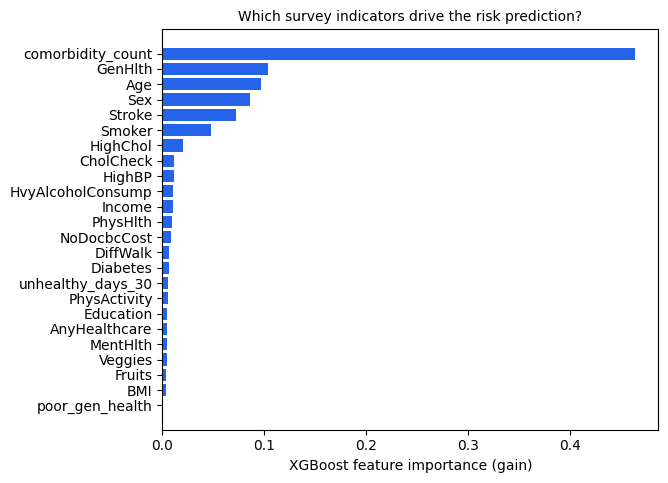

In [17]:
importances = xgb_final.feature_importances_
order = np.argsort(importances)
fig, ax = plt.subplots(figsize=(6.4, 5.2))
ax.barh(np.array(FEATURE_COLS)[order], importances[order], color="#2563eb")
ax.set_xlabel("XGBoost feature importance (gain)")
ax.set_title("Which survey indicators drive the risk prediction?", fontsize=10)
plt.show()

# Error Analysis

### False Negatives by Comorbidity Count

In [18]:
fn_mask = (yte == 1) & (xgb_pred == 0)
n_fn = int(fn_mask.sum())
n_pos_test = int(yte.sum())
print(f"\nXGBoost, default 0.5 threshold: {n_fn:,} false negatives out of {n_pos_test:,} true cases in the test set")

fn_df = test.loc[fn_mask].copy()
fn_df["predicted_probability"] = xgb_proba[fn_mask]
fn_df_sorted = fn_df.sort_values("predicted_probability")
cols_to_show = ["comorbidity_count", "HighBP", "HighChol", "Stroke", "DiffWalk", "predicted_probability"]

print("\n-- 10 lowest-confidence false negatives (model was most sure they were healthy) --")
print(fn_df_sorted[cols_to_show].head(10).to_string(index=False))

print("\n-- 10 highest-confidence false negatives (just missed the 0.5 cutoff) --")
print(fn_df_sorted[cols_to_show].tail(10).to_string(index=False))

print("\n-- False-negative predicted probability by comorbidity count --")
print(fn_df.groupby("comorbidity_count")["predicted_probability"].agg(["count", "mean", "min", "max"]).round(4))


XGBoost, default 0.5 threshold: 4,286 false negatives out of 4,743 true cases in the test set

-- 10 lowest-confidence false negatives (model was most sure they were healthy) --
 comorbidity_count  HighBP  HighChol  Stroke  DiffWalk  predicted_probability
               0.0       0         0       0         0               0.002055
               0.0       0         0       0         0               0.002150
               0.0       0         0       0         0               0.002216
               0.0       0         0       0         0               0.002242
               0.0       0         0       0         0               0.002377
               0.0       0         0       0         0               0.002606
               0.0       0         0       0         0               0.002874
               0.0       0         0       0         0               0.002922
               0.0       0         0       0         0               0.003000
               0.0       0         0     

# Cost-Sensitive Threshold Analysis

### Cost Functions and Default Threshold

In [19]:
COST_RATIOS = [1, 5, 10, 20, 50]

def expected_cost(y_true, y_pred, ratio):
    fn = np.sum((y_true == 1) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    return ratio * fn + fp

def best_threshold_for_ratio(y_val, proba_val, ratio, grid=None):
    if grid is None:
        grid = np.linspace(0.01, 0.99, 99)
    costs = [expected_cost(y_val, (proba_val >= t).astype(int), ratio) for t in grid]
    costs = np.array(costs)
    best_idx = np.argmin(costs)
    return float(grid[best_idx]), float(costs[best_idx])

default_pred = (xgb_proba >= 0.5).astype(int)
print(f"\nDefault threshold (0.5): acc={accuracy_score(yte, default_pred):.4f}  "
      f"recall={recall_score(yte, default_pred):.4f}  precision={precision_score(yte, default_pred):.4f}")


Default threshold (0.5): acc=0.8994  recall=0.0964  precision=0.5763


### Cost Ratio Sweep

In [20]:
thresholds, recalls, precisions = [], [], []
cost_default_vals, cost_optimal_vals = [], []
print()
for r in COST_RATIOS:
    t_star, _ = best_threshold_for_ratio(yval, xgb_val_proba, r)
    pred_te = (xgb_proba >= t_star).astype(int)
    thresholds.append(t_star); recalls.append(recall_score(yte, pred_te)); precisions.append(precision_score(yte, pred_te, zero_division=0))
    cost_default_vals.append(expected_cost(yte, default_pred, r))
    cost_optimal_vals.append(expected_cost(yte, pred_te, r))
    print(f"Cost ratio {r:3d}:1 -> threshold={t_star:.2f}  acc={accuracy_score(yte,pred_te):.4f}  "
          f"recall={recall_score(yte,pred_te):.4f}  precision={precision_score(yte,pred_te,zero_division=0):.4f}")


Cost ratio   1:1 -> threshold=0.50  acc=0.8994  recall=0.0964  precision=0.5763
Cost ratio   5:1 -> threshold=0.16  acc=0.7983  recall=0.6696  precision=0.2920
Cost ratio  10:1 -> threshold=0.08  acc=0.6819  recall=0.8545  precision=0.2254
Cost ratio  20:1 -> threshold=0.06  acc=0.6290  recall=0.8942  precision=0.2040
Cost ratio  50:1 -> threshold=0.02  acc=0.4296  recall=0.9724  precision=0.1503


### Threshold Sweep Plot

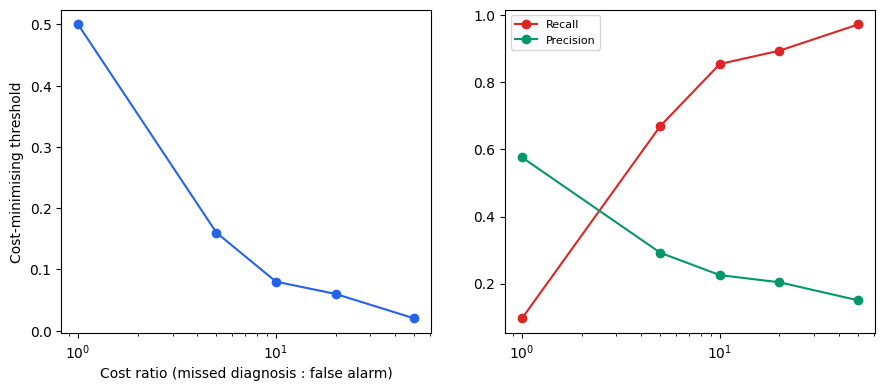

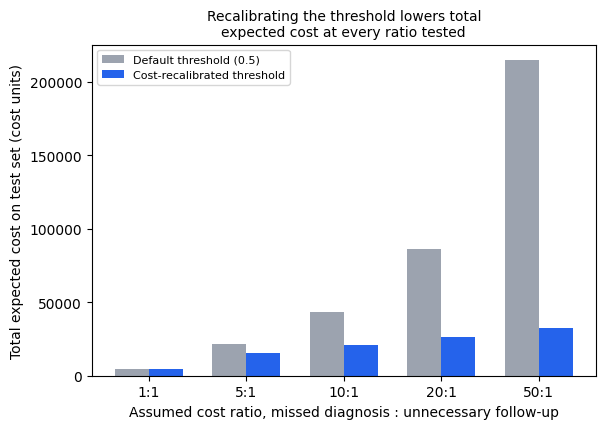

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
axes[0].plot(COST_RATIOS, thresholds, "o-", color="#2563eb"); axes[0].set_xscale("log")
axes[0].set_xlabel("Cost ratio (missed diagnosis : false alarm)"); axes[0].set_ylabel("Cost-minimising threshold")
axes[1].plot(COST_RATIOS, recalls, "o-", label="Recall", color="#dc2626")
axes[1].plot(COST_RATIOS, precisions, "o-", label="Precision", color="#059669")
axes[1].set_xscale("log"); axes[1].legend(fontsize=8)
plt.show()

x = np.arange(len(COST_RATIOS)); w = 0.35
fig, ax = plt.subplots(figsize=(6.5, 4.3))
ax.bar(x - w/2, cost_default_vals, width=w, label="Default threshold (0.5)", color="#9ca3af")
ax.bar(x + w/2, cost_optimal_vals, width=w, label="Cost-recalibrated threshold", color="#2563eb")
ax.set_xticks(x); ax.set_xticklabels([f"{r}:1" for r in COST_RATIOS])
ax.set_xlabel("Assumed cost ratio, missed diagnosis : unnecessary follow-up")
ax.set_ylabel("Total expected cost on test set (cost units)")
ax.set_title("Recalibrating the threshold lowers total\nexpected cost at every ratio tested", fontsize=10)
ax.legend(fontsize=8)
plt.show()

# Practical Screening Policy Evaluation

### Trivial Policies and Model-Driven Policy

In [25]:
HEADLINE_RATIO = 10
n = len(yte); n_pos = int(yte.sum())
screen_none_cost = expected_cost(yte, np.zeros(n, dtype=int), HEADLINE_RATIO)
screen_all_cost = expected_cost(yte, np.ones(n, dtype=int), HEADLINE_RATIO)
print(f"Screen nobody:  cost={screen_none_cost:,.0f}")
print(f"Screen everybody: cost={screen_all_cost:,.0f}")

t_star, _ = best_threshold_for_ratio(yval, xgb_val_proba, HEADLINE_RATIO)
model_pred = (xgb_proba >= t_star).astype(int)
model_cost = expected_cost(yte, model_pred, HEADLINE_RATIO)
n_flagged = int(model_pred.sum()); n_caught = int(np.sum((yte == 1) & (model_pred == 1)))
print(f"Model-driven (threshold={t_star:.2f}): cost={model_cost:,.0f} (flags {n_flagged:,}, catches {n_caught:,}/{n_pos:,})")

Screen nobody:  cost=47,430
Screen everybody: cost=41,214
Model-driven (threshold=0.08): cost=20,828 (flags 17,981, catches 4,053/4,743)
Screen nobody:  cost=47,430
Screen everybody: cost=41,214
Model-driven (threshold=0.08): cost=20,828 (flags 17,981, catches 4,053/4,743)


### Random-Flagging Significance Check

In [26]:
rng = np.random.default_rng(0)
n_perm = 2000
perm_costs = np.empty(n_perm)
for i in range(n_perm):
    idx = rng.choice(n, size=n_flagged, replace=False)
    rp = np.zeros(n, dtype=int); rp[idx] = 1
    perm_costs[i] = expected_cost(yte, rp, HEADLINE_RATIO)
pct = (perm_costs > model_cost).mean()
print(f"\nModel beats {pct:.1%} of {n_perm} random-flagging trials "
      f"(mean random cost={perm_costs.mean():,.0f})")



Model beats 100.0% of 2000 random-flagging trials (mean random cost=44,995)


### Policy Comparison Plot

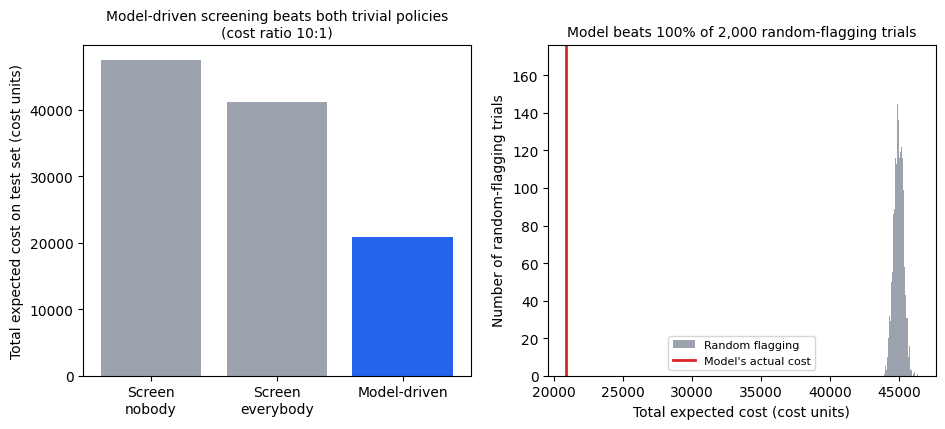

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
axes[0].bar(["Screen\nnobody", "Screen\neverybody", "Model-driven"], [screen_none_cost, screen_all_cost, model_cost], color=["#9ca3af","#9ca3af","#2563eb"])
axes[0].set_ylabel("Total expected cost on test set (cost units)")
axes[0].set_title(f"Model-driven screening beats both trivial policies\n(cost ratio {HEADLINE_RATIO}:1)", fontsize=10)

axes[1].hist(perm_costs, bins=40, color="#9ca3af", label="Random flagging")
axes[1].axvline(model_cost, color="#dc2626", linewidth=2, label="Model's actual cost")
axes[1].set_xlabel("Total expected cost (cost units)")
axes[1].set_ylabel("Number of random-flagging trials")
axes[1].set_title(f"Model beats {pct:.0%} of {n_perm:,} random-flagging trials", fontsize=10)
axes[1].legend(fontsize=8)
plt.show()